# Public Investment Map: research walkthrough
**CIS 509 · Team 4 · John Wheeler, Ryan Wolff, Cameron Anthony**

**Project repository:** [Public Investment Map on GitHub](https://github.com/intreaction/neighborhood-sentiment-map). The repository provides the source code, data documentation, methods, and run instructions for this notebook and the interactive map.

This is the readable data-build entry point for **Public Investment Map**; **Place Lab** is its interactive map. Run all cells from a fresh kernel to inspect the checked-in datasets, reproduce the area measures and baseline evaluation, and export the JSON files the page reads. Saved outputs make the same story readable on GitHub.

**Question:** How can historical business-review activity and language help a public planner investigate an area and compare evidence around past investments?

**Conclusion:** The data support historical evidence exploration. They do not validate a recommendation for where or how much to invest. Learned text did not improve our held-out project predictions, and the simpler model's advantage disappears under timing exclusions.

Reading order: (1) sources and research development, (2) quality and coverage, (3) ZIP dataset, (4) historical project outcomes, (5) text methods, with executed VADER, rule, BERT-embedding and BERTopic analyses and a label validation in 5.1–5.5, (6) model tests, (7) interpretation, (8) page export.

**Run:** Python 3.12, the repository's `requirements.txt` plus `requirements-notebook.txt`. No raw Yelp archive, API key, or sibling course folder is needed for this prepared-data walkthrough. Section 5.4 downloads the public `all-MiniLM-L6-v2` model (about 91 MB) on first run. The full raw extraction and text-model training are separate, documented stages. This notebook does not claim to rerun them.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root = Path.cwd().resolve()
while not (root / "src/place_pipeline.py").exists() and root != root.parent:
    root = root.parent
if not (root / "src/place_pipeline.py").exists():
    raise FileNotFoundError("Open this notebook within the cloned repository.")
sys.path.insert(0, str(root / "src"))
from place_pipeline import load_inputs, derive_areas, build_payloads, validate_payloads, export_payloads
inputs = load_inputs(root)
evidence, model, advanced = (inputs[k] for k in ("project_evidence", "project_model", "advanced_text"))
pd.set_option("display.max_columns", 14)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
print("Verified aggregate snapshots and evidence/model version compatibility.")

Verified aggregate snapshots and evidence/model version compatibility.


## 1. Where the data came from—and how the question developed

The original sources are **Yelp's January 2022 Open Dataset**, Census ACS income/poverty estimates, Census ZCTA boundaries, and published project costs/dates/geometry. OpenStreetMap supplies street-map context; it is not the source of our review outcomes. ZIP and ZCTA are related but not identical geographic definitions.

Our earlier ZIP-level study compared USAspending obligations with review sentiment. It did not detect a robust relationship after ZIP/time controls; administrative funding locations and review coverage limited interpretation. That led to named-project comparisons with explicit opening windows, nearby/comparison cohorts, and reported costs. We then tested text features, retained the better simple model, and built the map to inspect the evidence rather than promise causal returns.

See `analysis/PREREGISTRATION.md`, `docs/atlas-exploration.md`, `docs/project-source-audit.md`, and `docs/advanced-text-method.md`. These are stages of the research, not interchangeable estimates.

The following files are **prepared aggregate inputs**, not original raw data. Baseline profiles and geometry were frozen from the previous published extraction. Running this notebook reads these snapshots rather than recycling its own `web/` outputs. Their manifest records the upstream paths, hashes, and extraction modules. Refreshing them is an explicit upstream operation (`python src/prepare_place_inputs.py`).

In [2]:
lineage = pd.DataFrame([{"prepared_input": name, "origin_and_transformation": description}
                        for name, description in inputs["manifest"]["lineage"].items()])
display(lineage)
display(pd.DataFrame([{"artifact": name, "version": inputs[name]["version"]}
                     for name in ("project_evidence", "project_model", "advanced_text")]))

,prepared_input,origin_and_transformation
0,baseline_profiles.json,build_place_data.py: full Yelp January 2022 ar...
1,map_geometry.json,build_place_data.py: existing simplified Censu...
2,sentiment_zip_quarter.csv,build_sentiment_panel.py: Yelp review text sco...
3,access_quarters.json,build_review_topics.py: existing keyword-rule ...
4,income.csv,Earlier course ACS extracts: 2007–2011 Philade...
5,metro_zips.json,Existing atlas study ZIP membership; retained ...
6,yelp_zip_summary.csv,build_zip_universe.py: business inventory from...


,artifact,version
0,project_evidence,project-evidence-v1
1,project_model,project-ce-v2
2,advanced_text,tfidf-bigram-nmf5-v1


## 2. Data quality, coverage, and units

There are three distinct units: **ZIP areas** for map evidence, **historical projects** for model evaluation, and **business locations** for a fixed 500 m sample. Review counts are not independent training examples for the project model. Shared reviews also reduce independence across project catchments.

Missing or unsupported estimates remain null. A missing estimate is not a measured zero. The archive is historical, not a current census; reviews are not representative resident surveys. Costs are nominal reported totals with inconsistent public/private scope.

In [3]:
profiles = inputs["baseline_profiles.json"]
coverage = pd.DataFrame([{
    "city": c["label"], "archived_business_locations": len(c["businesses"]),
    "businesses_with_2018_2019_reviews": c["baseline_reviewed_businesses"],
    "baseline_reviews": c["baseline_reviews"]} for c in profiles["cities"]])
display(coverage)
display(pd.Series({k: evidence["coverage"][k] for k in (
    "n_projects", "n_eligible_projects", "unique_reviews_scored",
    "review_project_period_memberships", "reviews_shared_across_projects",
    "n_missing_text_reviews")}, name="project extraction audit").to_frame())

,city,archived_business_locations,businesses_with_2018_2019_reviews,baseline_reviews
0,Philadelphia,22052,16653,268091
1,Tampa Bay,22633,18408,299687
2,Nashville,8450,6624,142922
3,New Orleans,9601,7553,205693
4,Tucson,9839,8060,111642


,project extraction audit
n_projects,11
n_eligible_projects,10
unique_reviews_scored,1063956
review_project_period_memberships,1420312
reviews_shared_across_projects,292924
n_missing_text_reviews,0


## 3. Build the ZIP dataset from existing quarterly analysis

We compare **2012–2014** with **2019–2021**, two equal three-year windows. Sentiment is a review-weighted VADER average, not an average of quarter averages. Relative sentiment subtracts the change in the rest of the study metro, excluding the selected ZIP. Both periods need 100 reviews for a change measure.

- Activity: later reviews / 3 / mapped square kilometres (including water).
- Activity change: 100 × (later reviews / earlier reviews − 1).
- Access discussion: 100 × access/parking mentions / later reviews; includes praise and complaints.
- Income and poverty: historical ACS five-year estimates; not reviewer income.

`compute_areas` in `src/build_place_areas.py` implements these rules and verifies that independently prepared topic and sentiment review denominators match.

In [4]:
quarters = pd.DataFrame(inputs["sentiment_zip_quarter.csv"])
print(f"Quarterly source rows: {len(quarters):,}; ZIP identifiers: {quarters.zip5.nunique()}")
display(quarters.head(5))
areas = derive_areas(inputs)
zip_data = pd.DataFrame([{
    "city": city["id"], "zip": a["zip"], "area_km2": a["area_km2"],
    "yelp_listings": a["business_inventory"],
    "reviews_2012_2014": a["early"]["reviews"], "reviews_2019_2021": a["late"]["reviews"],
    "annual_reviews_per_km2": a["annual_review_density"], "review_growth_pct": a["growth_pct"],
    "sentiment_change": a["sentiment_change"], "sentiment_change_vs_metro": a["relative_sentiment_change"],
    "access_mentions_pct": a["access_share_pct"], "median_household_income": a["median_income"],
    "income_margin_of_error": a["income_moe"], "poverty_pct": a["poverty_pct"], "acs_end_year": a["acs_year"]
} for city in areas["cities"] for a in city["areas"]])
assert not zip_data.duplicated(["city", "zip"]).any()
print(f"Map dataset: {len(zip_data)} ZIP/ZCTA areas. Full rows are exported in section 8.")
display(zip_data.head(8).round(3))
display(zip_data.isna().sum().rename("missing_or_unsupported").to_frame())

Quarterly source rows: 9,168; ZIP identifiers: 277


,zip5,quarter,n_reviews,mean_compound,mean_stars,pct_negative
0,19100,2012Q1,4,0.8869,4.250,0.0
1,19100,2012Q2,10,0.9142,4.900,0.0
2,19100,2012Q3,8,0.9252,4.750,0.0
3,19100,2013Q1,4,0.9317,5.000,0.0
4,19100,2013Q2,4,0.8450,5.000,0.0


Map dataset: 196 ZIP/ZCTA areas. Full rows are exported in section 8.


,city,zip,area_km2,yelp_listings,reviews_2012_2014,reviews_2019_2021,annual_reviews_per_km2,...,sentiment_change,sentiment_change_vs_metro,access_mentions_pct,median_household_income,income_margin_of_error,poverty_pct,acs_end_year
0,Philadelphia,19128,18.342,387,3288,4661,84.707,...,-0.085,-0.014,5.020,61216.0,3161.0,11.364,2011.0
1,Philadelphia,19124,13.427,182,567,974,24.180,...,-0.234,-0.164,2.567,28988.0,1613.0,32.396,2011.0
2,Philadelphia,19133,3.307,41,97,232,23.382,...,NaN,NaN,1.293,14586.0,1405.0,54.026,2011.0
3,Philadelphia,19125,3.960,429,6332,7285,613.235,...,-0.077,-0.005,3.377,39319.0,3961.0,23.152,2011.0
4,Philadelphia,19116,13.450,185,1049,1422,35.242,...,-0.079,-0.007,2.039,56014.0,4589.0,10.852,2011.0
5,Philadelphia,19136,14.614,187,921,1223,27.896,...,-0.053,0.019,2.944,42492.0,2878.0,17.033,2011.0
6,Philadelphia,19114,15.063,234,1165,2434,53.863,...,-0.057,0.014,3.410,53070.0,3024.0,7.492,2011.0
7,Philadelphia,19118,8.465,203,1924,1724,67.890,...,-0.128,-0.056,3.480,80950.0,11008.0,5.846,2011.0


,missing_or_unsupported
city,0
zip,0
area_km2,0
yelp_listings,0
reviews_2012_2014,0
reviews_2019_2021,0
annual_reviews_per_km2,16
review_growth_pct,20
sentiment_change,20
sentiment_change_vs_metro,20


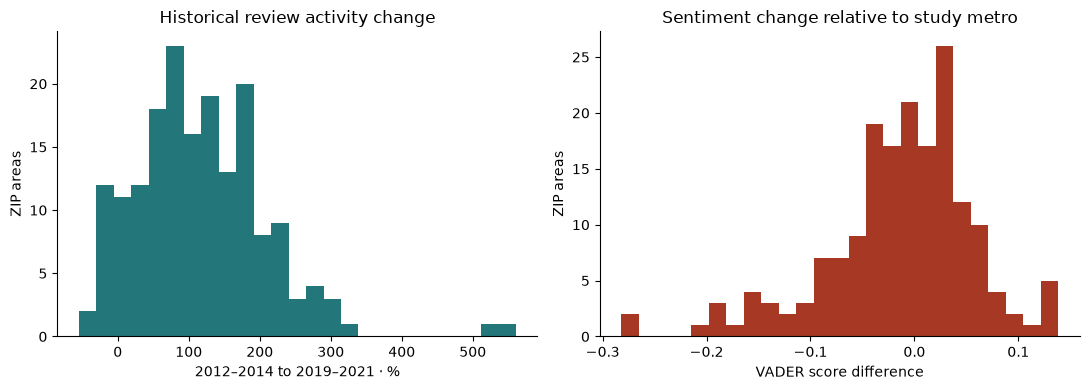

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
zip_data.review_growth_pct.dropna().plot.hist(bins=25, ax=axes[0], color="#23767a")
axes[0].set(title="Historical review activity change", xlabel="2012–2014 to 2019–2021 · %", ylabel="ZIP areas")
zip_data.sentiment_change_vs_metro.dropna().plot.hist(bins=25, ax=axes[1], color="#a63824")
axes[1].set(title="Sentiment change relative to study metro", xlabel="VADER score difference", ylabel="ZIP areas")
plt.tight_layout(); plt.show()

**Interpretation:** Large review-growth percentages can reflect small early denominators, platform adoption, and changing coverage. The later window includes COVID-19. A ZIP with relatively improving sentiment may still have declining absolute sentiment. None of these measures identifies a project's effect.

The map colors ZIP polygons using these exact values. Selecting a ZIP does not retrain a model or infer street-level differences within it.

## 4. Historical project dataset and outcome construction

For a historical project, the nearby cohort is within 500 m of a mapped footprint or explicit center proxy; the comparison band is 1.5–8 km away. We use the project's specified pre/post windows, which differ from the map's fixed 2018–2019 sample.

**CE = [near post reviews − near pre reviews × (comparison post / comparison pre)] / cost in $M.**

This is growth-adjusted review activity per reported dollar, not financial return or a causal effect. All 11 projects stay visible; insufficient-baseline cases are withheld from model fitting.

In [6]:
project_data = pd.DataFrame([{
    "project_id": p["id"], "project": p["project"], "city": p["city"],
    "geometry": p["geometry_quality"], "cost_millions": p["cost_millions"],
    "pre_years": ",".join(map(str, p["pre_years"])), "post_years": ",".join(map(str, p["post_years"])),
    "baseline_reviewed_businesses": p["features"]["near_baseline_reviewed"],
    "near_pre_reviews": p["periods"]["near"]["pre"]["n_reviews"],
    "near_post_reviews": p["periods"]["near"]["post"]["n_reviews"],
    "comparison_pre_reviews": p["periods"]["far"]["pre"]["n_reviews"],
    "comparison_post_reviews": p["periods"]["far"]["post"]["n_reviews"],
    "eligible": p["primary"]["eligible"], "exclusion_reason": p["primary"]["reason"],
    "ce_reviews_per_million": p["primary"]["ce_reviews_per_million"]
} for p in evidence["projects"]])
recomputed = (project_data.near_post_reviews - project_data.near_pre_reviews *
              project_data.comparison_post_reviews / project_data.comparison_pre_reviews) / project_data.cost_millions
eligible = project_data.eligible
np.testing.assert_allclose(recomputed[eligible], project_data.loc[eligible, "ce_reviews_per_million"])
display(project_data[["project", "city", "geometry", "cost_millions", "baseline_reviewed_businesses", "eligible", "ce_reviews_per_million"]].round(2))
display(project_data.loc[~eligible, ["project", "exclusion_reason"]])

,project,city,geometry,cost_millions,baseline_reviewed_businesses,eligible,ce_reviews_per_million
0,Lafitte,New Orleans,mapped_footprint,9.1,243,True,127.29
1,Sun Link,Tucson,mapped_footprint,196.5,278,True,-11.23
2,Dilworth Park,Philadelphia,mapped_footprint,55.0,859,True,60.01
3,Water Works Park,Tampa,mapped_footprint,7.4,7,False,NaN
4,Riverfront / Ascend,Nashville,mapped_footprint,52.0,123,True,124.24
5,Tampa Riverwalk,Tampa,center_proxy,32.0,98,True,5.42
6,Schuylkill Boardwalk,Philadelphia,center_proxy,18.0,81,True,-42.57
7,The Rail Park,Philadelphia,mapped_footprint,10.3,231,True,99.42
8,Crescent Park,New Orleans,center_proxy,31.2,28,True,-7.27
9,Indianapolis Cultural Trail,Indianapolis,center_proxy,63.0,176,True,-20.26


,project,exclusion_reason
3,Water Works Park,Insufficient baseline support: at least 20 nea...


Sun Link nearby reviews: 3,807 → 10,943.
Adjusted outcome: -11.23 reviews/$1M.


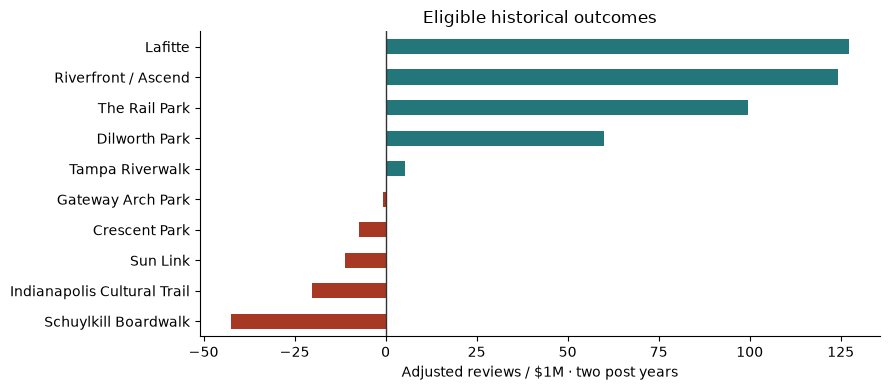

In [7]:
sun = project_data.set_index("project").loc["Sun Link"]
print(f"Sun Link nearby reviews: {sun.near_pre_reviews:,} → {sun.near_post_reviews:,}.")
print(f"Adjusted outcome: {sun.ce_reviews_per_million:.2f} reviews/$1M.")
ordered = project_data[eligible].sort_values("ce_reviews_per_million")
ax = ordered.plot.barh(x="project", y="ce_reviews_per_million", legend=False,
                      color=["#23767a" if v >= 0 else "#a63824" for v in ordered.ce_reviews_per_million])
ax.axvline(0, color="#333", linewidth=1)
ax.set(xlabel="Adjusted reviews / $1M · two post years", ylabel="", title="Eligible historical outcomes")
plt.tight_layout(); plt.show()

**What this changed in our interpretation:** Sun Link's raw review volume grew, yet growth lagged its comparison area. Negative adjusted CE does not mean the project failed on transit, mobility, or public welfare. This distinction is why the app exposes raw counts alongside the adjusted result.

## 5. How unstructured text contributes

The upstream pipeline applies whole-review VADER and provisional clause-level topic/target/polarity rules. Explicit outdoor context helps distinguish an area's cleanliness from a restaurant's bathroom, for example. Independent human precision/recall has **not** yet been established. Section 5.5 reports accuracy against agent labels (Claude Opus, blind to rule output), pending human recheck.

The advanced stage learns an 8,000-feature TF-IDF unigram/bigram representation and five NMF topics. Descriptive topics fit only sampled baseline reviews; later reviews are transformed through that frozen basis. Predictive challengers refit the text representation inside each holdout and exclude shared held-out review IDs. The descriptive and predictive topic bases are different.

Below we inspect saved, versioned NLP results—not rerun text fitting from aggregate data. Full raw-text regeneration uses `build_project_evidence.py`, `build_advanced_text.py`, and `train_project_model.py`.

In [8]:
topic_terms = pd.DataFrame([{"topic": t["id"], "leading_terms": ", ".join(t["top_terms"]),
                             "basis": advanced["version"]} for t in advanced["topics"]])
display(topic_terms)
display(pd.Series({k: advanced["coverage"][k] for k in (
    "unique_selected_reviews", "unique_baseline_fit_reviews", "learned_vocabulary_size")}, name="NLP coverage").to_frame())
print("Independently human-reviewed labels:", evidence["quality"]["independently_human_reviewed"])
text_results = pd.DataFrame([{
    "project": p["project"], "band": band, "period": period, "reviews": v["n_reviews"],
    "mean_sentiment": v["mean_sentiment"], "place_discussion_share": v["place_discussion_share"],
    "access_friction_share": v["access_friction_share"],
    "public_realm_complaint_share": v["public_realm_complaint_share"]
} for p in evidence["projects"] for band in ("near", "far")
  for period, v in p["periods"][band].items()])
display(text_results.query("band == 'near' and period == 'pre'").round(4))

,topic,leading_terms,basis
0,topic_1,"chicken, good, food, ordered, fried, sauce, ch...",tfidf-bigram-nmf5-v1
1,topic_2,"just, like, time, room, don, people, hotel, di...",tfidf-bigram-nmf5-v1
2,topic_3,"great, food, good, place, service, bar, friend...",tfidf-bigram-nmf5-v1
3,topic_4,"pizza, crust, slice, best, ny, place, best piz...",tfidf-bigram-nmf5-v1
4,topic_5,"ice, cream, ice cream, coffee, tea, chocolate,...",tfidf-bigram-nmf5-v1


,NLP coverage
unique_selected_reviews,23691
unique_baseline_fit_reviews,10971
learned_vocabulary_size,8000


Independently human-reviewed labels: 0


,project,band,period,reviews,mean_sentiment,place_discussion_share,access_friction_share,public_realm_complaint_share
1,Lafitte,near,pre,3554,0.7223,0.1500,0.0104,0.0158
7,Sun Link,near,pre,3807,0.7575,0.0507,0.0066,0.0053
13,Dilworth Park,near,pre,17260,0.7300,0.0475,0.0041,0.0047
19,Water Works Park,near,pre,49,0.7274,0.0408,0.0000,0.0204
25,Riverfront / Ascend,near,pre,2441,0.7248,0.0537,0.0074,0.0070
31,Tampa Riverwalk,near,pre,1510,0.7401,0.1152,0.0119,0.0073
37,Schuylkill Boardwalk,near,pre,1512,0.6886,0.1349,0.0079,0.0146
43,The Rail Park,near,pre,8805,0.6941,0.0402,0.0042,0.0035
49,Crescent Park,near,pre,606,0.7966,0.1650,0.0033,0.0281
55,Indianapolis Cultural Trail,near,pre,2199,0.7474,0.0637,0.0095,0.0036


**Finding:** Many learned terms concern food and service. That is evidence about what Yelp captures, not a reason to relabel those topics as civic satisfaction. Whole-review sentiment, access mentions, and area-targeted negative clauses answer different questions. The page's access heatmap uses mention frequency; it does not use the project-specific negative-clause rate.

### 5.1 The review text we can rerun here

Sections 5.1–5.5 execute natural-language methods from the course on real review text. They run on the **413 short excerpts** already published in `data/derived/project_evidence.json`, so no raw Yelp archive is needed. The excerpts are not a random sample: the clause rules selected them as area-related mentions near or around a project, at most 240 characters each. Star ratings belong to the whole review.

Course connections: VADER and bag-of-words classifiers (Week 2, Lab 2), deep-learning text classification (Week 3–4, Lab 3), and BERT for text classification and BERTopic topic modeling (Week 6, Lab 4).

,excerpts,projects,median characters,truncated at 240
0,413,11,84,7


period,post,pre,All
rule topic,,,
cleanliness_maintenance,26,17,43
construction,13,17,30
neighborhood,33,30,63
parking,33,30,63
public_space,33,31,64
safety,25,19,44
transit,23,22,45
walking_accessibility,33,28,61
All,219,194,413


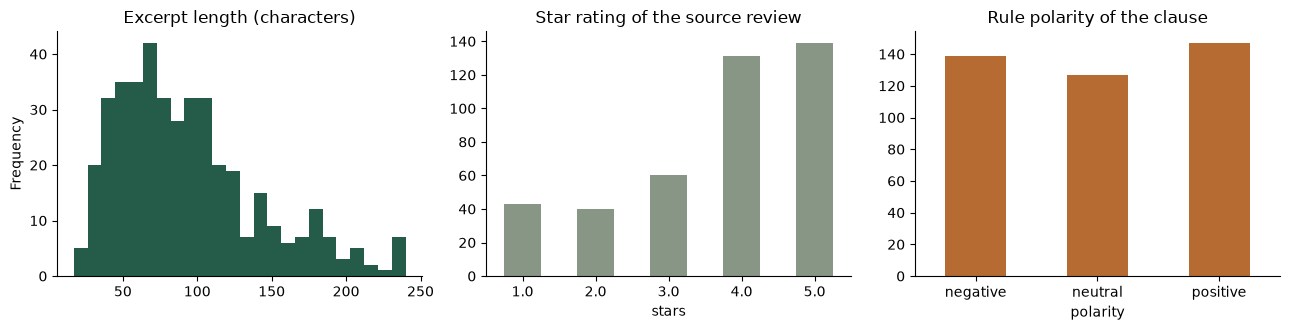

In [9]:
from review_nlp import load_excerpts, star_sentiment_benchmark, fit_bertopic, EMBEDDING_MODEL
excerpts = load_excerpts(evidence)
display(pd.DataFrame({"excerpts": [len(excerpts)], "projects": [excerpts.project.nunique()],
                      "median characters": [int(excerpts.chars.median())], "truncated at 240": [int(excerpts.truncated.sum())]}))
display(pd.crosstab(excerpts.topic, excerpts.period, margins=True).rename_axis(index="rule topic", columns="period"))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
excerpts.chars.plot.hist(bins=24, ax=axes[0], color="#245c49", title="Excerpt length (characters)")
excerpts.stars.value_counts().sort_index().plot.bar(ax=axes[1], color="#889686", title="Star rating of the source review", rot=0)
excerpts.polarity.value_counts().reindex(["negative", "neutral", "positive"]).plot.bar(ax=axes[2], color="#b56b32", title="Rule polarity of the clause", rot=0)
plt.tight_layout(); plt.show()

### 5.2 Lexicon sentiment with VADER (Lab 2)

VADER scores text from a sentiment lexicon plus rules for negation, intensifiers and punctuation, without training data. We rerun it here and compare it with the stored scores and with the star rating of each source review.

Rerun matches the stored clause score for 408 of 413 excerpts; 5 of the 5 differences are excerpts truncated at 240 characters (stored scores used the full clause).


,count,mean VADER compound
stars,,
1.0,43,-0.150
2.0,40,0.118
3.0,60,0.138
4.0,131,0.053
5.0,139,0.159


Spearman correlation, stars vs VADER: 0.146


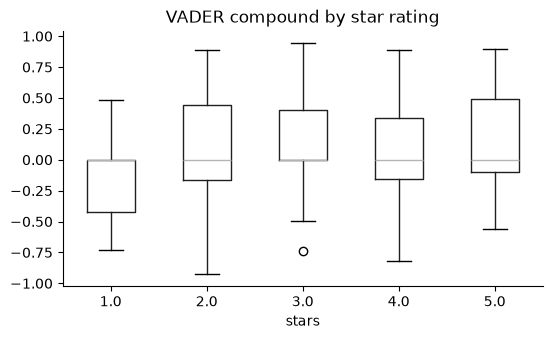

In [10]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()
excerpts["vader"] = [vader.polarity_scores(t)["compound"] for t in excerpts.text]
same = np.isclose(excerpts.vader, excerpts.compound, atol=1e-4)
print(f"Rerun matches the stored clause score for {same.sum()} of {len(excerpts)} excerpts; "
      f"{(~same & excerpts.truncated).sum()} of the {(~same).sum()} differences are excerpts truncated at 240 characters (stored scores used the full clause).")
by_star = excerpts.groupby("stars").vader.agg(["count", "mean"]).round(3)
display(by_star.rename(columns={"mean": "mean VADER compound"}))
print("Spearman correlation, stars vs VADER:", round(excerpts[["stars", "vader"]].corr("spearman").iloc[0, 1], 3))
ax = excerpts.boxplot(column="vader", by="stars", grid=False, figsize=(6, 3.4))
ax.set_title("VADER compound by star rating"); ax.set_xlabel("stars"); plt.suptitle(""); plt.show()

### 5.3 Clause rules on worked examples

The rules split a review into clauses, tag topics by keyword, decide whether each clause is about the **area** or the **business**, and assign polarity from VADER plus explicit complaint phrases. The examples include cases the rules get right and cases they get wrong.

In [11]:
from project_text import analyze_text
examples = [
    "Parking is impossible on this street.",
    "The staff were rude but the park across the street is lovely.",
    "The neighborhood is not unsafe at all.",
    "Their bathroom was dirty.",
    "Street parking was a nightmare, but the tacos made up for it.",
    "Easy walk from the streetcar stop.",
]
rows = []
for text in examples:
    hits = analyze_text(text)["evidence"]
    rows += [{"text": text, "topic": h["topic"], "target": h["target"], "polarity": h["polarity"]} for h in hits] or [{"text": text, "topic": "(no topic)", "target": "", "polarity": ""}]
display(pd.DataFrame(rows))

,text,topic,target,polarity
0,Parking is impossible on this street.,parking,area,negative
1,The staff were rude but the park across the st...,food_service_value,business,negative
2,The staff were rude but the park across the st...,public_space,area,positive
3,The neighborhood is not unsafe at all.,safety,area,neutral
4,The neighborhood is not unsafe at all.,neighborhood,area,neutral
5,Their bathroom was dirty.,cleanliness_maintenance,business,negative
6,"Street parking was a nightmare, but the tacos ...",parking,area,neutral
7,Easy walk from the streetcar stop.,transit,area,positive


**Reading the examples:** the rules separate a restaurant's bathroom (business) from the street (area), and split "the staff were rude but the park … is lovely" into a negative business clause and a positive area clause. They also fail in ways that matter: "Street parking was a nightmare" is labelled **neutral** because neither the complaint phrases nor VADER treat "nightmare" as negative here, "not unsafe at all" stays neutral rather than reassuring, and "Easy walk from the streetcar stop" is tagged as transit but not as walking. Section 5.5 measures how often misses like these happen.

### 5.4 BERT sentence embeddings (Week 6)

`all-MiniLM-L6-v2`, the sentence-transformer used for BERTopic in Lab 4, maps each excerpt to a 384-dimensional embedding. The first run downloads the model (about 91 MB) from Hugging Face. We use the embeddings two ways:

1. **Classification:** predict whether the source review was positive (4–5 stars) or negative (1–2 stars) from the excerpt, compared with VADER, a Lab 2 bag-of-words Naive Bayes model, and a majority-class reference (5-fold cross-validation).
2. **Topic modeling:** BERTopic (UMAP → HDBSCAN → c-TF-IDF), compared with the keyword topics.

In [12]:
from sentence_transformers import SentenceTransformer
encoder = SentenceTransformer(EMBEDDING_MODEL)
embeddings = encoder.encode(excerpts.text.tolist(), batch_size=64, show_progress_bar=False)
print("Embedding matrix:", embeddings.shape)
display(star_sentiment_benchmark(excerpts, embeddings).round(3))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding matrix: (413, 384)


,method,n,accuracy,macro_f1
0,Majority class,353,0.765,0.433
1,VADER (compound ≥ 0.05),353,0.479,0.469
2,Bag of words + Naive Bayes,353,0.773,0.587
3,MiniLM embeddings + logistic regression,353,0.654,0.579


**Interpretation:** about three-quarters of the source reviews are positive, so the majority-class reference is already high. The embedding classifier and Naive Bayes improve macro-F1 over VADER, but none of the methods predicts stars well from a short place-related clause. A four-star review can still complain about parking. Stars are a weak label for clauses, which is why Section 5.5 uses clause-level labels instead.

In [13]:
topic_model, bert_topics = fit_bertopic(excerpts.text.tolist(), embeddings, encoder)
info = topic_model.get_topic_info()
display(info.loc[info.Topic >= 0, ["Topic", "Count", "Name"]].head(12))
excerpts["bertopic"] = bert_topics
display(pd.crosstab(excerpts.bertopic, excerpts.topic).rename_axis(index="BERTopic topic (-1 = outliers)", columns="rule topic"))

,Topic,Count,Name
1,0,84,0_parking_street_garage_lot
2,1,31,1_restaurant_pizza_think_restaurants
3,2,29,2_clean_downtown_place_good
4,3,26,3_hotel_minutes_walk_didn
5,4,22,4_sketchy_neighborhood_little_night
6,5,19,5_park_water_characters_nice
7,6,19,6_subway_don_like_sandwich
8,7,13,7_distance_walking_area_art
9,8,12,8_streetcar_canal_short_beer
10,9,9,9_construction_noise_going_block


rule topic,cleanliness_maintenance,construction,neighborhood,parking,public_space,safety,transit,walking_accessibility
BERTopic topic (-1 = outliers),,,,,,,,
-1,18,6,22,10,18,15,11,24
0,1,9,0,46,18,2,3,5
1,3,1,7,2,6,1,4,7
2,9,1,10,1,0,4,0,4
3,1,2,3,4,5,2,2,7
4,0,0,9,0,0,13,0,0
5,3,1,0,0,13,2,0,0
6,0,0,2,0,0,0,17,0
7,0,1,0,0,0,0,1,11


**Finding:** on area-related excerpts, BERTopic recovers civic themes without being told them: parking (its largest topic), neighbourhood safety ("sketchy … night"), streetcars, construction noise and trash. Several learned topics line up with a single rule topic. Two caveats show why topic labels need reading: one topic mixes subway trains with *Subway* sandwich shops, and another is about restaurants and pizza. The TF-IDF/NMF topics in Section 5 were fitted to all reviews and found mostly food and service, so selecting place-related text first is what makes civic topics appear. HDBSCAN leaves about a third of the excerpts as outliers (topic −1).

### 5.5 How accurate are the rules? Validation against labelled clauses

The 731-item annotation sample (200 random reviews, 200 random keyword-screen clauses, 331 project/period/topic-stratified clauses) was labelled for target, topics and polarity by **Claude Opus acting as an annotator**. The annotator saw only the text, not VADER or rule output. **These are agent labels pending human recheck, not independent human validation.** Review text stays out of the repository; `data/derived/text_validation/agent_labels.csv` holds the labels under hashed review keys, and `metrics.json` the results. When the local sample exists, this cell recomputes the metrics and checks them against the saved file.

The comparison also trains a BERT-embedding classifier on the same labels, cross-validated with folds grouped by business so a business never appears in both training and test data.

Recomputed rule and VADER metrics from the local labelled sample; they match the saved file.
Agent labels pending human recheck; not independent human validation. Items: 731 Confidence: {'medium': 309, 'high': 395, 'low': 27}


,task,method,precision,recall,F1
0,Clause is about the area,Keyword rules,0.683,0.713,0.698
1,Clause is about the area,MiniLM + logistic regression,0.745,0.800,0.771
2,Negative comment about the area,Keyword rules,0.387,0.164,0.231
3,Negative comment about the area,MiniLM + logistic regression,0.418,0.699,0.523


,method,accuracy,macro-F1 (positive / negative / neutral),n
0,VADER,0.621,0.560,488
1,MiniLM + logistic regression,0.676,0.618,488


Random reviews mentioning a place: 61 of 200 (95% CI 25%–37%). Keyword screen recall 0.80, precision 0.36.


,precision,recall,support
walking_accessibility,0.79,0.66,74.0
transit,0.61,0.85,27.0
parking,0.93,0.91,103.0
safety,0.41,0.67,36.0
cleanliness_maintenance,0.72,0.88,98.0
public_space,0.45,0.67,51.0
construction,0.78,1.00,32.0
food_service_value,0.85,0.21,189.0
neighborhood,0.71,0.50,109.0


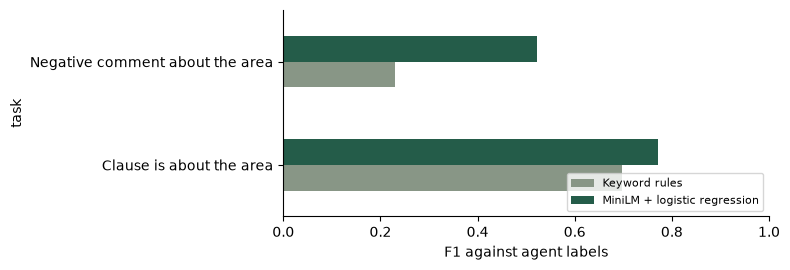

In [14]:
from text_validation import evaluate
metrics = json.loads((root / "data/derived/text_validation/metrics.json").read_text())
local = root / "data/interim/project_evidence/agent_labels.json"
if local.exists():
    recomputed = evaluate(json.loads(local.read_text())["records"])
    for key in ("area_target", "negative_area", "random_reviews"):
        assert json.dumps(recomputed[key], sort_keys=True) == json.dumps(metrics[key], sort_keys=True), key
    print("Recomputed rule and VADER metrics from the local labelled sample; they match the saved file.")
else:
    print("Local labelled sample not present; showing saved metrics.")
print(metrics["labels"]["status"], "Items:", metrics["labels"]["n_items"], "Confidence:", metrics["labels"]["confidence"])

bench = metrics["embedding_benchmark"]
def row(task, method, s):
    return {"task": task, "method": method, "precision": s["precision"], "recall": s["recall"], "F1": s["f1"]}
comparison = pd.DataFrame([
    row("Clause is about the area", "Keyword rules", bench["area_target"]["rules"]),
    row("Clause is about the area", "MiniLM + logistic regression", bench["area_target"]["embedding_lr"]),
    row("Negative comment about the area", "Keyword rules", bench["negative_area"]["rules"]),
    row("Negative comment about the area", "MiniLM + logistic regression", bench["negative_area"]["embedding_lr"]),
])
display(comparison.round(3))
pol = bench["polarity"]
display(pd.DataFrame([{"method": "VADER", **pol["vader"]}, {"method": "MiniLM + logistic regression", **pol["embedding_lr"]}]).assign(n=pol["n"]).round(3)
        .rename(columns={"macro_f1": "macro-F1 (positive / negative / neutral)"}))
rr = metrics["random_reviews"]
print(f"Random reviews mentioning a place: {rr['with_place_mention']} of {rr['n']} "
      f"(95% CI {rr['place_rate_ci'][0]:.0%}–{rr['place_rate_ci'][1]:.0%}). Keyword screen recall {rr['keyword_screen']['recall']:.2f}, precision {rr['keyword_screen']['precision']:.2f}.")
topics = pd.DataFrame(metrics["topics"]).T[["precision", "recall", "tp", "fn"]].assign(support=lambda d: d.tp + d.fn)
display(topics.drop(columns=["tp", "fn"]).astype(float).round(2))
ax = comparison.pivot(index="task", columns="method", values="F1").plot.barh(figsize=(8, 2.8), color=["#889686", "#245c49"])
ax.set_xlabel("F1 against agent labels"); ax.set_xlim(0, 1); ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

**What this changes:**

- **Area targeting is moderate** (rules F1 ≈ 0.70). **Negative area comments are weak:** the rules find about one in six that the annotator found (recall ≈ 0.16). The "negative access" and "negative public space" measures in Place Lab therefore undercount complaints and should be read as low-reliability indicators.
- **BERT embeddings help on every task.** A simple classifier on MiniLM embeddings raises F1 for negative area comments from about 0.23 to about 0.52, mostly by finding complaints the keywords miss, and beats VADER on clause polarity. It is not yet applied to the full 1.06 M-review corpus; rescoring requires the raw archive and is the clearest next step.
- **VADER mislabels negative place comments:** many clauses the annotator read as negative score neutral or positive, because the review around them praises the food.
- **About 30% of random reviews mention a place at all.** The keyword screen catches about 80% of them but also flags many irrelevant reviews, which the target step must then filter.
- All figures carry the agent-label caveat and the per-label support shown. Human rechecking may change them.

## 6. Reproduce the baseline and inspect alternatives

The independent prediction unit is a project: ten eligible outcomes in seven cities. The baseline uses log(1+x) cost, reviewed-business count, and reviews per reviewed business. Scaling is learned inside each fold; ridge alpha is fixed at 10. We compare leave-one-project-out and leave-one-city-out errors.

The next cell actually refits the baseline from the current aggregate inputs and checks it against saved predictions. The subsequent challenger table reports saved evaluations; regenerating NMF challenger folds requires the local review corpus.

In [15]:
from sklearn.model_selection import LeaveOneOut, LeaveOneGroupOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

rows = model["training_rows"]
features = model["candidates"]["baseline"]["feature_names"]
X = np.log1p([[r["inputs"][name] for name in features] for r in rows])
y = np.array([r["observed_ce"] for r in rows])
groups = np.array([r["city"] for r in rows])
pipeline = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
for label, splits in [("project", list(LeaveOneOut().split(X))),
                      ("city", list(LeaveOneGroupOut().split(X, y, groups)))]:
    predictions = cross_val_predict(pipeline, X, y, cv=splits)
    saved = [r[f"{label}_prediction"] for r in model["candidates"]["baseline"]["held_out"]]
    np.testing.assert_allclose(predictions, saved, rtol=1e-8, atol=1e-8)
    print(f"Reproduced {label}-held-out MAE: {mean_absolute_error(y, predictions):.2f} reviews/$1M")
comparison = pd.DataFrame([{
    "model": name, "project_MAE": candidate["project_metrics"]["mae"],
    "city_MAE": candidate["city_metrics"]["mae"],
    "city_direction_accuracy": candidate["city_metrics"]["sign_accuracy"]
} for name, candidate in {"mean_only": model["mean_baseline"], **model["candidates"]}.items()])
display(comparison.round(3))

Reproduced project-held-out MAE: 49.33 reviews/$1M
Reproduced city-held-out MAE: 45.61 reviews/$1M


,model,project_MAE,city_MAE,city_direction_accuracy
0,mean_only,61.616,58.485,0.5
1,baseline,49.328,45.609,0.6
2,text,53.096,48.189,0.5
3,trend,51.520,46.255,0.6
4,advanced_text,53.043,46.671,0.6


,sample,projects,baseline_city_MAE,mean_city_MAE
0,All eligible projects,10,45.61,58.48
1,exclude_pandemic_post_windows,8,60.29,59.53
2,exclude_pandemic_and_construction_overlap,7,70.21,61.65


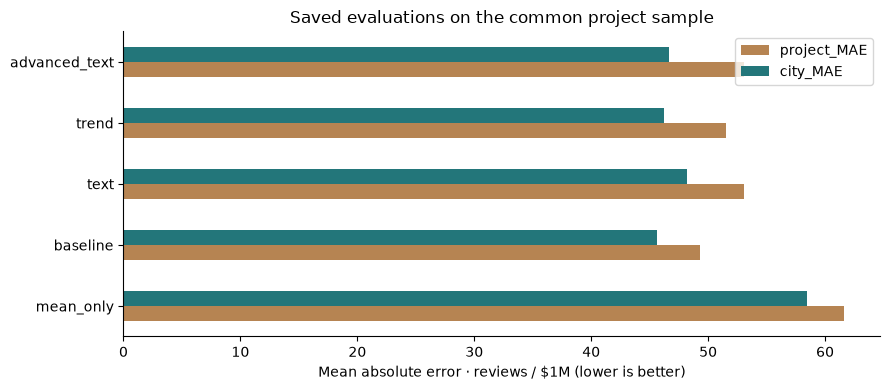

In [16]:
sensitivity = pd.DataFrame([{"sample": "All eligible projects", "projects": model["n_projects"],
    "baseline_city_MAE": model["candidates"]["baseline"]["city_metrics"]["mae"],
    "mean_city_MAE": model["mean_baseline"]["city_metrics"]["mae"]}] + [
    {"sample": name, "projects": value["n_projects"],
     "baseline_city_MAE": value["candidates"]["baseline"]["city_metrics"]["mae"],
     "mean_city_MAE": value["mean_baseline"]["city_metrics"]["mae"]}
    for name, value in model["sensitivities"].items()])
display(sensitivity.round(2))
ax = comparison.plot.barh(x="model", y=["project_MAE", "city_MAE"], color=["#b68452", "#23767a"])
ax.set(xlabel="Mean absolute error · reviews / $1M (lower is better)", ylabel="", title="Saved evaluations on the common project sample")
plt.tight_layout(); plt.show()

## 7. Conclusions and responsible use

1. **Use the map to identify questions for local investigation.** A high access-mention share calls for reading the evidence; it does not prove an accessibility problem.
2. **Compare outcomes with their counterfactual assumptions visible.** Sun Link illustrates why raw growth alone is insufficient; our comparison band is still observational, not a randomized control.
3. **Keep the simpler exploratory model.** Text challengers did not improve both holdouts. More review text does not create more independent project outcomes.
4. **Do not optimize a public budget from this model.** Timing exclusions remove the baseline's advantage over the mean. Error envelopes are historical errors, not calibrated confidence intervals.
5. **Treat negative-comment rates as low-reliability.** Against agent labels, the keyword rules find about one in six negative area comments; BERT embeddings roughly double F1 but are not yet applied to the full corpus.
6. **Keep geographic scales explicit.** ZIP colors describe area data. The interactive model uses a fixed 500 m sample at an interior reference point, not a ZIP-wide benefit estimate. Project type selects comparables; it is not a fitted effect.

Next evidence needed: human recheck of the agent labels, rescoring the corpus with the embedding classifier, verified footprints and cost scope, more projects, current local observations, and evaluation outside model selection. These are limitations, not completed validation.

## 8. Export the dataset and the page's data contract

This cell is the publishing step. It validates all five payloads, then writes the exact files fetched by `src/place_app.js`:

| Output | Meaning |
|---|---|
| `web/place-areas.json` | Recomputed ZIP heatmap measures |
| `web/place-timeline.json` | Monthly ZIP and metro review sums behind the map timeline |
| `web/place-data.json` | Prepared 2018–2019 business-location profiles |
| `web/place-map.json` | Prepared geographic boundaries |
| `web/place-model.json` | Current fitted project model and validation |
| `web/place-history.json` | Historical activity and text-chart series |

`web/place-build-manifest.json` records source, code, notebook-source, and output hashes. Human-readable CSV exports are written to `data/derived/notebook_dataset/`. No raw review text or review/business IDs are exported. ZIP identifiers must be read as strings; blank numeric CSV cells mean missing/unsupported, not zero. `*_share` is a fraction; `*_pct` is a percentage. CE and MAE are reviews per nominal $1M over two post years; income is historical nominal dollars.

In [17]:
payloads = build_payloads(inputs, areas)
summary = validate_payloads(payloads)
display(pd.Series(summary, name="validated export coverage").to_frame())
manifest = export_payloads(payloads, inputs, root / "web")
export_folder = root / "data/derived/notebook_dataset"
export_folder.mkdir(parents=True, exist_ok=True)
exports = {"zip_evidence.csv": zip_data, "historical_projects.csv": project_data,
           "project_text_results.csv": text_results, "learned_topic_terms.csv": topic_terms,
           "model_comparison.csv": comparison, "timing_sensitivity.csv": sensitivity}
for filename, table in exports.items():
    table.to_csv(export_folder / filename, index=False)
display(pd.DataFrame([{"file": name, "rows": len(table), "columns": len(table.columns)}
                      for name, table in exports.items()]))
print("Exported all five page datasets and the build manifest. No browser or raw extraction required.")

,validated export coverage
cities,5
ZIPs,196
profile_records,72575
historical_projects,11


,file,rows,columns
0,zip_evidence.csv,196,15
1,historical_projects.csv,11,15
2,project_text_results.csv,66,8
3,learned_topic_terms.csv,5,3
4,model_comparison.csv,5,4
5,timing_sensitivity.csv,3,4


Exported all five page datasets and the build manifest. No browser or raw extraction required.


## 9. Read, run, and audit the implementation

- Open the page with `python src/serve_place.py --port 8766`; the browser reads the exported JSON, not the notebook.
- UI-only rebuild: `python src/build_place_site.py` and `npm ci && npm run build:place`.
- Python tests: `python -m unittest discover -s tests -p 'test_*.py'`.
- Browser calculation tests: `node --test tests/*.test.cjs tests/*.test.mjs`.

**Reader check:** Why can positive raw review growth coexist with negative adjusted CE? Look at Sun Link's near growth and the comparison growth factor in section 4. The latter establishes the expected count; the adjusted outcome subtracts that expectation, not the baseline count.

**AI disclosure:** OpenAI Codex and Anthropic Claude (Claude Code, with Claude Opus models) assisted with code, debugging, analysis checks, interface work, slides and drafting. Claude Opus also produced the 731 validation labels in section 5.5, working from the review text alone. Team members remain responsible for understanding and verifying the submitted sources, methods, results, and interpretation. Independent human annotation of those labels has not been completed.